In [64]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh
from scipy.signal import welch

gs.set_graph_style(1)

def gaussian_func(x, a, sigma):
    return a * np.exp(-((x) ** 2) / (sigma**2))

def exp_func(x, a, sigma):
    return a * np.exp(-(x) / (sigma))

def exp_sin_func(x, a, sigma, f, phi, a_s):
    A = a + a_s*np.sin(2 * np.pi * f * x + phi)
    return A * np.exp(-(x) / (sigma))

def load_data(rid, day):
    result = fh.load_result(rid=rid, day=day, experiment="fastgates")
    print(result["datasets"].keys())
    A = result["datasets"][f"ndscan.rid_{rid}.analysis_result.ion_phase_contrast"]
    A_err = result["datasets"][f"ndscan.rid_{rid}.analysis_result.ion_phase_contrast_err"]
    b = np.array(result["datasets"][f"ndscan.rid_{rid}.points.axis_1"])*1000 # in ms
    return b, A, A_err

def unpack_data(rid, day):
    b, A, A_err = load_data(rid, day)
    contrasts = A
    contrast_errors = A_err
    times = np.unique(b)
    times = np.sort(times)
    return times, contrasts, contrast_errors


In [80]:

rid = 136437
day = "2026-08-11"
delays, contrast, contrast_err = unpack_data(rid, day)

argsort = np.argsort(delays)
delays = delays[argsort]
contrast = contrast[argsort]
contrast_err = contrast_err[argsort]

popt, pcov = curve_fit(
    exp_func,
    delays,
    contrast,
    sigma=contrast_err,
    p0=[1, 10],
)
print(f"Fitted parameters: {popt}")
p_err = np.sqrt(np.diag(pcov))
print(f"Coherence time: {popt[1]:.3e} ± {p_err[1]:.3e} s")
print(f"Amplitude: {popt[0]:.3e} ± {p_err[0]:.3e}")

x_fit = np.linspace(np.min(delays), np.max(delays), 1000)
y_fit = exp_func(x_fit, *popt)

def heating_decay(t, A, nbar_dot):
    return A/(1 + nbar_dot * t)**2

nbardot = 33/1000
nbardot_err = 3/1000
t_heat = (np.sqrt(np.e) - 1)/nbardot
t_heat_upper = (np.sqrt(np.e) - 1)/(nbardot - nbardot_err)
t_heat_lower = (np.sqrt(np.e) - 1)/(nbardot + nbardot_err)
# y_fit_heat = heating_decay(x_fit, popt[0], t_heat)
# y_fit_heat_upper = heating_decay(x_fit, popt[0], t_heat_upper)
# y_fit_heat_lower = heating_decay(x_fit, popt[0], t_heat_lower)
y_fit_heat = heating_decay(x_fit, popt[0], nbardot)
y_fit_heat_upper = heating_decay(x_fit, popt[0], nbardot - nbardot_err)
y_fit_heat_lower = heating_decay(x_fit, popt[0], nbardot + nbardot_err)


""" Remove baseline decay from data and fft to see spectrum"""
osc = contrast - heating_decay(delays, popt[0], nbardot)
# osc = contrast - exp_func(delays, *popt)
osc = osc - np.mean(osc)
delays_s = delays/1000

nyquist_freq = 1/(2*(delays_s[1]-delays_s[0])) # in Hz
print(f"Nyquist frequency: {nyquist_freq:.2f} Hz")

fs = 1 / np.mean(np.diff(delays_s))  # Sampling frequency in Hz

freq, psd = welch(
    osc,
    fs=fs,
    window='hann',
    nperseg=len(osc),
    nfft=2048
)

psd = psd / np.max(psd)  # Normalize the PSD

dict_keys(['ndscan.rid_136437.analysis_result.coherence_time', 'ndscan.rid_136437.analysis_result.coherence_time_err', 'ndscan.rid_136437.analysis_result.ion_phase_contrast', 'ndscan.rid_136437.analysis_result.ion_phase_contrast_err', 'ndscan.rid_136437.analysis_results', 'ndscan.rid_136437.annotations', 'ndscan.rid_136437.axes', 'ndscan.rid_136437.channels', 'ndscan.rid_136437.completed', 'ndscan.rid_136437.fragment_fqn', 'ndscan.rid_136437.ndscan_schema_revision', 'ndscan.rid_136437.online_analyses', 'ndscan.rid_136437.points.axis_0', 'ndscan.rid_136437.points.axis_1', 'ndscan.rid_136437.points.channel_counts', 'ndscan.rid_136437.points.channel_is_brights', 'ndscan.rid_136437.points.channel_measurement_camera_readout_p', 'ndscan.rid_136437.points.channel_measurement_camera_readout_p_0', 'ndscan.rid_136437.points.channel_measurement_camera_readout_p_err', 'ndscan.rid_136437.points.channel_measurement_camera_readout_p_err_0', 'ndscan.rid_136437.points.channel_measurement_crystal_p', 'n

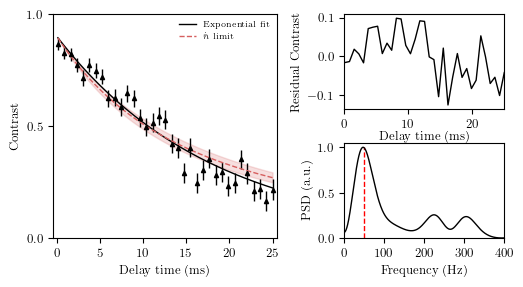

In [84]:

fig_width = gs.get_fig_width()
fig_height = fig_width * 1/2

fig = plt.figure(figsize=(fig_width, fig_height))

grids = fig.add_gridspec(
    2, 2,
    width_ratios=[1.4, 1],  # left plot slightly wider
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.35
)

# Left: spans both rows
ax_left = fig.add_subplot(grids[:, 0])

# Right: one plot per row
ax_top = fig.add_subplot(grids[0, 1])
ax_bottom = fig.add_subplot(grids[1, 1])

ax_left.errorbar(delays, contrast, yerr=contrast_err, fmt="^", color="k")
ax_left.plot(x_fit, y_fit, color="k", label="Exponential fit", ls='-')
ax_left.plot(x_fit, y_fit_heat, color=gs.get_color(2), label=r"$\dot{\bar{n}}$ limit", ls='--')
ax_left.fill_between(x_fit, y_fit_heat_lower, y_fit_heat_upper, color=gs.get_color(2), alpha=0.2)
ax_left.set_xlabel("Delay time (ms)")
ax_left.set_ylabel("Contrast")
ax_left.set_xlim(-0.5, 25.5)
ax_left.set_ylim(0, 1)
ax_left.set_xticks([0, 5, 10, 15, 20, 25])
ax_left.set_yticks([0, 0.5, 1])
ax_left.legend(frameon=False, loc="upper right")
ax_left.grid(None)


ax_top.plot(delays, osc, color="k", label="Oscillations", ls='-')
ax_top.set_xlabel("Delay time (ms)", labelpad=0)
ax_top.set_ylabel("Residual Contrast")
ax_top.set_xlim(0, 25)
ax_bottom.vlines(50, 0, np.max(psd), color="r", ls="--") 
ax_bottom.plot(freq, psd, color="k", label="Power Spectral Density", ls='-')
ax_bottom.set_xlabel("Frequency (Hz)")
ax_bottom.set_ylabel("PSD (a.u.)")
ax_bottom.set_xlim(0, 400)
ax_bottom.set_ylim(0, 1.05)
ax_top.grid(None)
ax_bottom.grid(None)
f_name = "..\\..\\pdf_figure\\ch4\\mode_coherence.pdf"
plt.savefig(f_name, bbox_inches="tight")